# Customer Concentration — is a firm that leans on a few big customers riskier? 🔗
### And if it is, does the stock market actually pay you for that risk? In plain English

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

Imagine a small supplier that sells **80% of everything it makes to one giant customer** — say a parts maker whose whole business is one carmaker. If that customer walks, renegotiates, or goes bust, the supplier is in deep trouble. Its cash flows are *lumpy* and *fragile*. Accountants and academics call this **customer concentration**, and the claim is that concentrated firms are **riskier** — and, if markets are efficient, that you should be **paid a premium** for holding that extra risk.

We test both halves: does concentration raise a firm's forward **risk**, and does it come with a return **premium**?

> ⚠️ **Heads-up: this is a synthetic study.** There is no free, public dataset of who each company's big customers are (it's buried in paywalled filings). So we build a *realistic simulated world* where we can dial the effect up and down, and see what an honest test would find. That means the best this study can earn is **Weak** — never **Real** (which needs a real market tape).

> 📓 **This is the plain-language layer.** Want the *t*-stats, the placebo test and the cost maths? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> House style in [METHODOLOGY.md](../../../METHODOLOGY.md). **Not investment advice.**

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from customer_concentration import data, strategy as st

# SYNTHETIC-ONLY: no real customer-concentration tape exists (paywalled 10-K / Compustat segments).
# The headline panel plants both effects at literature-plausible strengths; all cells are offline.
PANEL, TRUTH = data.synthetic_panel()   # seed 573, vol_beta=0.35, ret_alpha=0.04
print("synthetic panel fp:", data.fingerprint(PANEL), "| n =", len(PANEL),
      "| planted vol_beta =", TRUTH["vol_beta"], ", ret_alpha =", TRUTH["ret_alpha"])
print("NOTE: synthetic-only study -> Signal capped at WEAK (no real tape to certify against).")


synthetic panel fp: bc1d5db4bfa5 | n = 400 | planted vol_beta = 0.35 , ret_alpha = 0.04
NOTE: synthetic-only study -> Signal capped at WEAK (no real tape to certify against).


## The answer first 🎯

| Question | Answer |
|---|---|
| Are concentrated firms *riskier* (more volatile)? | **Yes, clearly.** The most concentrated third had forward volatility **24.5%** vs **21.2%** for the most diversified third. The fragility is real. |
| Did they *earn more* (a premium)? | **A little, but it's noisy.** The concentrated third returned **+12.1%** vs **+7.2%** — a **+4.9%** gap in the right direction, but a shuffle test says the odds it's just luck are *p* = 0.102. Not convincing. |
| Could you trade the premium? | **No.** There's no index of 'concentrated firms' to buy, and the return gap is too shaky to bet on — it even vanishes at some cut points. |

> So: concentration looks like a genuine *risk*, but the *reward* for bearing it is hard to see — even in a world where we deliberately planted one. Riskier, yes; visibly paid for it, no.

## 1 · The claim

> *"Firms whose revenue depends on a few large customers bear more risk — and that risk should be priced."* — the customer-concentration literature (Patatoukas 2012; Dhaliwal, Judd, Serfling & Shaikh 2016; Hertzel et al. 2008).

The intuition: one big customer is a single point of failure. Lose it and revenue collapses. Distress even travels *up* the supply chain — when a big buyer stumbles, its concentrated suppliers get hurt. So a concentrated firm's future is *lumpier*: bigger swings, fatter tails. The textbook says risk should be **rewarded**, so these fragile firms *ought* to earn a premium. (Some researchers argue the opposite — a *discount* — if investors under-price the tail. The sign is genuinely up for grabs.)

## 2 · So what?

If concentration is a priced risk, it's a *fundamental* factor you could tilt toward (harvest the premium) or away from (avoid the fragility). It also matters for anyone analysing a single stock: a supplier riding on one customer deserves a fatter discount rate. The desk has looked at balance-sheet fragility ([540 Distress-Risk](../../540-distress-risk-anomaly/)); this is a different, *demand-side* kind of fragility.

## 3 · How would we even know?

1. **Score concentration.** For each firm, how lopsided is its customer base? One dominant customer → a high score; many small ones → a low score. (Formally a Herfindahl index of customer revenue shares.)
2. **Sort.** Split the firms into a *diversified* third and a *concentrated* third.
3. **Compare the future.** Did the concentrated third have (a) higher forward **volatility** — the risk claim — and (b) higher forward **returns** — the premium claim?

Because there's no free real customer data, we do this on a **simulated 400-firm world** where we control the truth. In the headline run we planted *both* effects (a real risk bump and a real premium) — then we ask whether an honest test can even *see* them.

*Timing:* concentration is measured *today* (the last filing); risk and return are measured over the *following* period. No peeking ahead.

## 4 · The teardown — let's actually look

**First the risk claim: were the concentrated firms more volatile?**

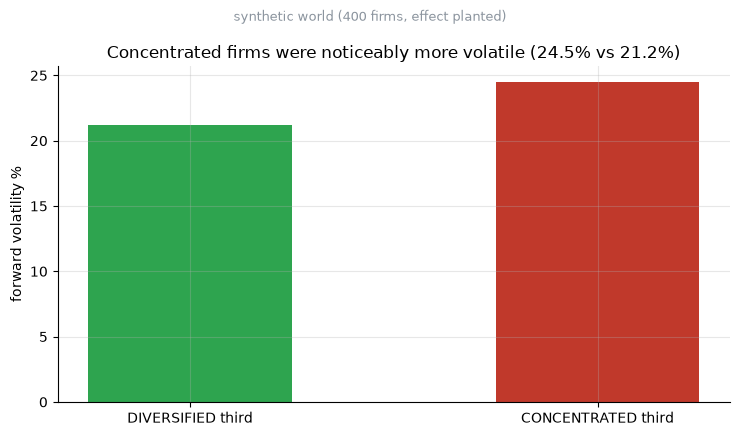

Diversified vol 21.2% | Concentrated vol 24.5% | spread +3.3pp (t +29.4)


In [2]:
b = st.bucket_stats(PANEL, frac=0.3)
div_v, conc_v, vspr, vt = b['div_vol']*100, b['conc_vol']*100, b['vol_spread']*100, st.vol_tstat(b)['t']
fig, ax = plt.subplots(figsize=(7.5, 4.4))
ax.bar(['DIVERSIFIED third','CONCENTRATED third'], [div_v, conc_v], color=[GREEN, RED], width=.5)
ax.set_ylabel('forward volatility %')
ax.set_title(f'Concentrated firms were noticeably more volatile ({conc_v:.1f}% vs {div_v:.1f}%)')
fig.suptitle('synthetic world (400 firms, effect planted)', fontsize=9, color=GREY)
plt.tight_layout(); plt.show()
print(f'Diversified vol {div_v:.1f}% | Concentrated vol {conc_v:.1f}% | spread +{vspr:.1f}pp (t {vt:+.1f})')

There's the risk story, loud and clear: the concentrated third's forward vol is **24.5%** against **21.2%** for the diversified third — a **+3.3pp** gap with a huge *t* (+29). Depending on a few big customers really does make the ride bumpier.

**Now the payoff claim: did the riskier firms actually *earn* more?**

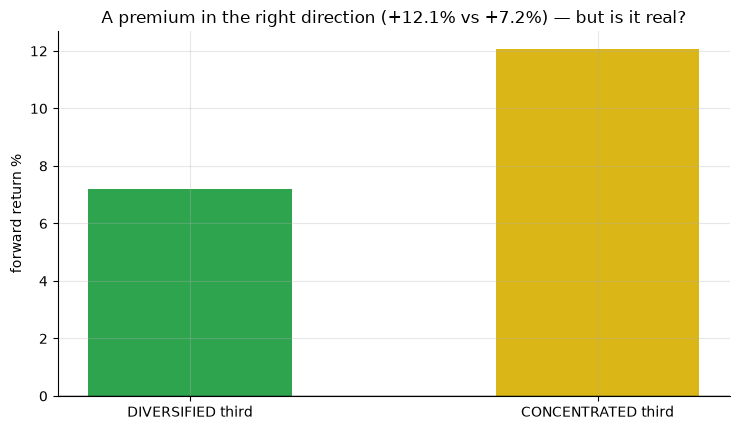

Diversified +7.2% | Concentrated +12.1% | spread +4.9% (t +1.61, shuffle p 0.102)


In [3]:
div_r, conc_r, rspr = b['div_ret']*100, b['conc_ret']*100, b['ret_spread']*100
rt = st.return_tstat(b)['t']; p = st.placebo_pvalue(PANEL, n_perm=2000, seed=573)
fig, ax = plt.subplots(figsize=(7.5, 4.4))
ax.bar(['DIVERSIFIED third','CONCENTRATED third'], [div_r, conc_r], color=[GREEN, AMBER], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('forward return %')
ax.set_title(f'A premium in the right direction (+{conc_r:.1f}% vs +{div_r:.1f}%) — but is it real?')
plt.tight_layout(); plt.show()
print(f'Diversified +{div_r:.1f}% | Concentrated +{conc_r:.1f}% | spread +{rspr:.1f}% (t {rt:+.2f}, shuffle p {p:.3f})')

The premium is *there* in direction — **+12.1%** vs **+7.2%** — but look at the *t* (+1.61) and the shuffle-test *p* (0.102). Those say: *could easily be luck.* Even though we **planted a real premium**, it's hard to see, because the same fragility that raises risk also makes the returns jump around — the signal drowns in its own noise.

**Does the answer depend on how we cut the buckets?**

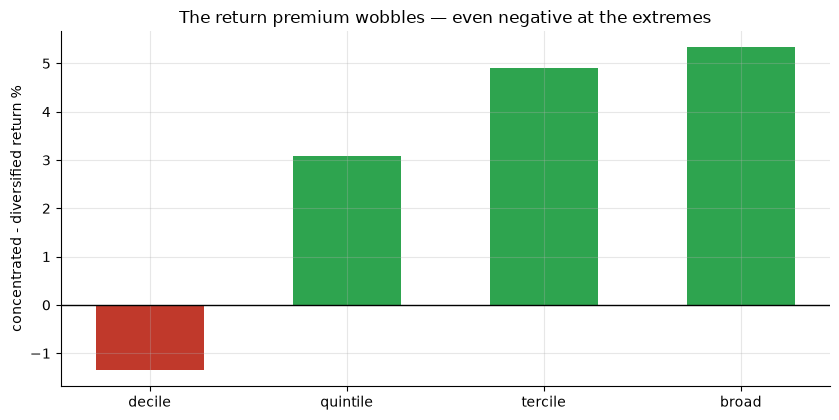

return spreads by cut: [-1.3, 3.1, 4.9, 5.3]


In [4]:
rows = st.robustness_sweep(PANEL)
labs = ['decile','quintile','tercile','broad']
rspr = [r['ret_spread']*100 for r in rows]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
cols = [GREEN if s>0 else RED for s in rspr]
ax.bar(labs, rspr, color=cols, width=.55)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('concentrated - diversified return %')
ax.set_title('The return premium wobbles — even negative at the extremes')
plt.tight_layout(); plt.show()
print('return spreads by cut:', [round(s,1) for s in rspr])

At the extreme deciles the 'premium' actually goes **negative**, then turns positive for wider buckets. A payoff that flips sign depending on where you draw the line is not something you can lean on. (The *risk* gap, by contrast, is rock-solid at every cut — see the quant notebook.)

## 5 · The verdict

- **Signal — Weak.** The *risk* half is strong and stable (concentrated firms are clearly more volatile). But the *return* half is soft even where we planted it (*t* +1.61, shuffle *p* 0.102), and there's no real market tape to certify anything — so, capped at Weak.
- **Tradability — Mirage.** No investable 'concentration' index exists, and the premium is too shaky and buried in noise to trade.

> Riskier? Plausibly yes. Paid for it? Not visibly.

## 6 · Could you actually trade it?

Not really. You'd have to (a) build the customer-concentration data yourself from thousands of filings, (b) somehow buy a basket of 'concentrated' firms and short 'diversified' ones, and (c) hope the premium — which our honest test can barely detect and which flips sign across cut points — actually shows up. Costs then nibble the already-soft gap (gross vs net in the quant notebook). No free lunch here.

## 7 · Going further 🚪

- **The risk vs the reward.** The lesson generalises: a factor can be a genuine *risk* and still not deliver a *tradable premium* — the reward can be real but too small and noisy to harvest.
- **Cousins on the desk.** [540 Distress-Risk](../../540-distress-risk-anomaly/) is balance-sheet fragility; [177 Megacap-Concentration](../../177-megacap-concentration/) is *index*-level concentration.

*Have real customer-concentration data (Compustat segments / hand-collected 10-Ks)? Fork this, drop it in, and see whether the return premium clears t = 2 on a real tape.*